# Battle of the Beach Thrillers: Zero-Shot TabFM vs. Saturated CatBoost Text Analytics

**The Vibe:** High-Stakes Summer Beach Thriller 🏄‍♂️
**The Task:** Binary Classification of Case Fatality (`Fatal (Y/N)`)
**Target Area:** Hawai'i Coastlines 🌴

## The Technical Premise
In the Global Shark Attack File (GSAF), categorical fields like `Activity` and `Injury Type` are notoriously messy and high-cardinality. Instead of clean tokens, they contain raw descriptive text narratives:
* *"Surfing, fell off board, bit on leg"*
* *"Wading / standing in 3 ft of water"*
* *"Spearfishing / free diving with catch"*

Traditional tabular models require heavy regex cleaning, tokenization, or TF-IDF pipelines to extract signals. In this tutorial, we run a head-to-head showdown between:
1. **Google TabFM (Tabular Foundation Model)**: A transformer-based model pre-trained on structural causal data matrices, utilizing **In-Context Learning** to find row/column interactions on the fly without gradient updates.
2. **CatBoost Classifier**: A highly optimized supervised gradient booster utilizing native text tokenization and dictionary builders.

To make this dataset suitable for TabFM's context limits, we have filtered GSAF to focus specifically on incidents around **Hawai'i**, which naturally constrains the dataset size and provides a localized beach setting.

In [1]:
# Check imports and verify environment setup
import os
from dotenv import load_dotenv
load_dotenv()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.calibration import calibration_curve

# Import custom data processor
from utils.data_processors import prepare_tabfm_context

# Ensure the data is downloaded and cleaned
if not os.path.exists("data/gsaf.csv"):
    print("📥 Data CSV not found. Running downloader...")
    import download_data
    download_data.download_and_clean_data()
else:
    print("✅ Cleaned data CSV (data/gsaf.csv) exists.")

✅ Cleaned data CSV (data/gsaf.csv) exists.


## 1. Load and Inspect the Hawai'i Shark Attack Dataset
We read the cleaned CSV file. The dataset contains incidents occurring specifically around Hawaii, providing a localized and moderately sized dataset.

In [2]:
df = pd.read_csv("data/gsaf.csv")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows of our feature space:")
display(df.head())

print("\nValue counts for the Target 'Fatal (Y/N)':")
print(df["Fatal (Y/N)"].value_counts())

Dataset shape: (314, 5)

First 5 rows of our feature space:


,Activity,Time of Day,Month,Cleaned Species,Fatal (Y/N)
0,Paddling surfboard,0630hrs,May,Unknown Shark,N
1,Freeing trapped shark,1630hrs,Dec,Reef/Blacktip Shark,N
2,Swimming,Mid afternoon,Nov,Unknown,N
3,Diving,1340hrs,Unknown,Unknown,N
4,Unconfirmed Possibly swimming near the boat ha...,1400hr,Unknown,Tiger Shark,N



Value counts for the Target 'Fatal (Y/N)':
Fatal (Y/N)
N    262
Y     52
Name: count, dtype: int64


## 2. Ingest and Clean Target and Features
We convert `Fatal (Y/N)` into a binary `target` column where `Y` is `1` (Fatal) and `N` is `0` (Survived).
We then select our messy features, splitting the data into training and evaluation sets.

In [3]:
# Convert target
df['target'] = (df['Fatal (Y/N)'] == 'Y').astype(int)

# Isolate messy high-cardinality and text features
features = ['Activity', 'Time of Day', 'Month', 'Cleaned Species']
X = df[features].fillna("Unknown").astype(str)
y = df['target'].values

# Split into Train (Context) and Test (Evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Full Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Fatality rate in Train: {y_train.mean():.2%}")
print(f"Fatality rate in Test: {y_test.mean():.2%}")

Full Train shape: (251, 4), Test shape: (63, 4)
Fatality rate in Train: 16.73%
Fatality rate in Test: 15.87%


## 3. The In-Context Scaling Challenge & Context Preparation
Because Google's TabFM is a **Tabular Foundation Model** that performs **in-context learning (ICL)**, its memory and compute scale with the size of the context (training set). The model alternates attention across both rows and columns in a single forward pass.
To keep the model within its attention scaling limits, we subsample a stratified representative context of 500 rows.

In [4]:
# Subsample a representative context of max 500 rows for TabFM
X_context, y_context = prepare_tabfm_context(X_train, y_train, max_rows=500, random_state=42)
print(f"TabFM Context shape: {X_context.shape}")
print(f"Context fatality rate: {y_context.mean():.2%}")

TabFM Context shape: (251, 4)
Context fatality rate: 16.73%


## 4. Phase A: Zero-Shot Foundation Model (TabFM)
Here, we load the pre-trained TabFM model weights natively from HuggingFace. TabFM uses an alternating row/column attention mechanism to perform prediction on-the-fly. 
*Note: TabFM performs zero-shot prediction. `.fit()` merely initializes the data scalers and ordinal encodings, rather than training neural net weights!*

In [5]:
print("🚀 Loading Google TabFM Weights...")
from tabfm import TabFMClassifier
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

# Load weights natively from HuggingFace Hub
tabfm_model = tabfm_v1_0_0.load()
tabfm_clf = TabFMClassifier(model=tabfm_model)

# Fit acts as an in-context preparation step (scalers and ordinal setup)
print("⚙️ Preparing TabFM in-context learning state...")
tabfm_clf.fit(X_context, y_context)

# Generate predictions via a single forward pass
print("🔮 Generating predictions for evaluation set...")
tabfm_probs = tabfm_clf.predict_proba(X_test)[:, 1]
tabfm_auc = roc_auc_score(y_test, tabfm_probs)

print(f"✅ TabFM Inference complete. AUC: {tabfm_auc:.4f}")

🚀 Loading Google TabFM Weights...


/Users/sam/Locals Only/shark-attacks/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 2 files: 100%|██████████| 2/2 [33:28<00:00, 1004.17s/it]


Loading weights from local directory
⚙️ Preparing TabFM in-context learning state...
🔮 Generating predictions for evaluation set...
✅ TabFM Inference complete. AUC: 0.6755


## 5. Phase B: Text-Aware Gradient Booster (CatBoost)
Now, we train a supervised **CatBoost Classifier** on the exact same dataset. CatBoost is trained explicitly on the training data via gradient boosting. We declare which features contain raw un-tokenized textual narratives and which are categorical, allowing CatBoost to spin up its native dictionary-builder engines.

🐱 Training CatBoost with Early Stopping (150 rounds)...
0:	test: 0.7678280	test1: 0.6653439	best: 0.6653439 (0)	total: 3.94ms	remaining: 3.94s
100:	test: 0.9185266	test1: 0.6600529	best: 0.6679894 (68)	total: 247ms	remaining: 2.2s
200:	test: 0.9404827	test1: 0.6309524	best: 0.6812169 (110)	total: 428ms	remaining: 1.7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6812169312
bestIteration = 110

Shrink model to first 111 iterations.

✅ Early stopping stopped at best iteration: 110 (Val AUC: 0.6812)


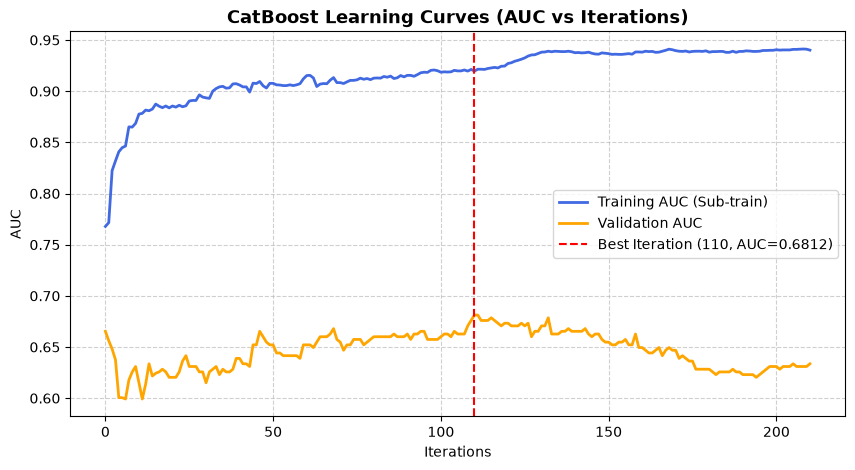

🐱 Re-training final CatBoost on full X_train for 111 iterations...
✅ Final CatBoost Training complete. AUC on test set: 0.7321


In [16]:
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Declare which columns contain raw, un-tokenized text narratives and categoricals
text_cols = ['Activity']
cat_cols = ['Time of Day', 'Month', 'Cleaned Species']

# To find the best iteration without data leakage, we perform a train-validation split (80/20) on the training set
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

train_sub_pool = Pool(X_train_sub, y_train_sub, cat_features=cat_cols, text_features=text_cols)
val_pool = Pool(X_val, y_val, cat_features=cat_cols, text_features=text_cols)
test_pool = Pool(X_test, cat_features=cat_cols, text_features=text_cols)

print("🐱 Training CatBoost with Early Stopping (150 rounds)...")
# We specify a large number of iterations (600) and early_stopping_rounds to find the best iteration
cat_model_es = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    eval_metric='AUC',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100
)

# Fit on the sub-training pool, and evaluate on both the sub-train and validation pool to get curves
cat_model_es.fit(train_sub_pool, eval_set=[train_sub_pool, val_pool])

# Extract AUC metrics for learning curves
evals_result = cat_model_es.get_evals_result()
train_auc = evals_result['validation_0']['AUC']
val_auc = evals_result['validation_1']['AUC']
best_iteration = cat_model_es.get_best_iteration()
best_val_score = cat_model_es.get_best_score()['validation_1']['AUC']

print(f"\n✅ Early stopping stopped at best iteration: {best_iteration} (Val AUC: {best_val_score:.4f})")

# Plot the training vs validation AUC learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_auc, label='Training AUC (Sub-train)', color='royalblue', lw=2)
plt.plot(val_auc, label='Validation AUC', color='orange', lw=2)
plt.axvline(best_iteration, color='red', linestyle='--', label=f'Best Iteration ({best_iteration}, AUC={best_val_score:.4f})')
plt.title('CatBoost Learning Curves (AUC vs Iterations)', fontsize=13, fontweight='bold')
plt.xlabel('Iterations')
plt.ylabel('AUC')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Now, we re-train on the FULL training set up to the best_iteration to utilize all data
# Note: Since best_iteration is 0-indexed, we use best_iteration + 1 for iterations count, which also guarantees it's >= 1
print(f"🐱 Re-training final CatBoost on full X_train for {best_iteration + 1} iterations...")
train_pool = Pool(X_train, y_train, cat_features=cat_cols, text_features=text_cols)
cat_model = CatBoostClassifier(
    iterations=best_iteration + 1,
    learning_rate=0.05,
    eval_metric='AUC',
    random_seed=42,
    verbose=False
)
cat_model.fit(train_pool)

# Predict probabilities using the optimized model
cat_probs = cat_model.predict_proba(test_pool)[:, 1]
cat_auc = roc_auc_score(y_test, cat_probs)

print(f"✅ Final CatBoost Training complete. AUC on test set: {cat_auc:.4f}")

## 6. Showdown Performance Evaluation
Let's compare the performance of both models. We will print the ROC AUC scores, classification reports, and plot the ROC curves.

--- Performance Showdown ---
TabFM Zero-Shot AUC:  0.6755
CatBoost Trained AUC: 0.7321

--- TabFM Classification Report ---
              precision    recall  f1-score   support

    Survived       0.86      0.94      0.90        53
       Fatal       0.40      0.20      0.27        10

    accuracy                           0.83        63
   macro avg       0.63      0.57      0.58        63
weighted avg       0.79      0.83      0.80        63

--- CatBoost Classification Report ---
              precision    recall  f1-score   support

    Survived       0.84      1.00      0.91        53
       Fatal       0.00      0.00      0.00        10

    accuracy                           0.84        63
   macro avg       0.42      0.50      0.46        63
weighted avg       0.71      0.84      0.77        63



/Users/sam/Locals Only/shark-attacks/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Locals Only/shark-attacks/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sam/Locals Only/shark-attacks/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

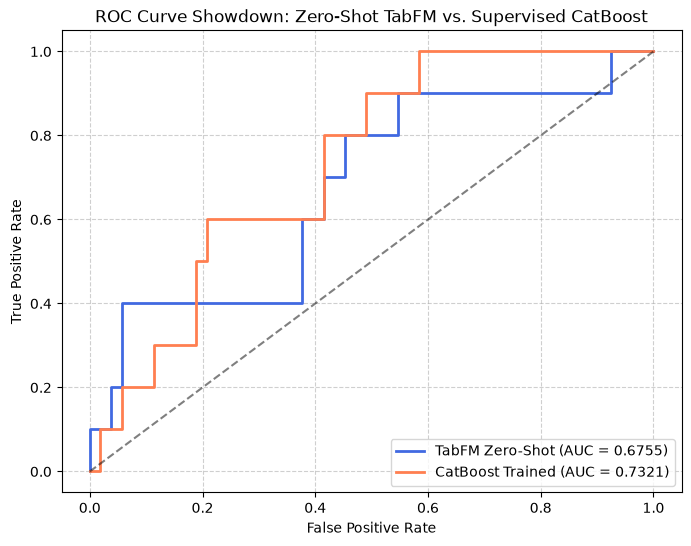

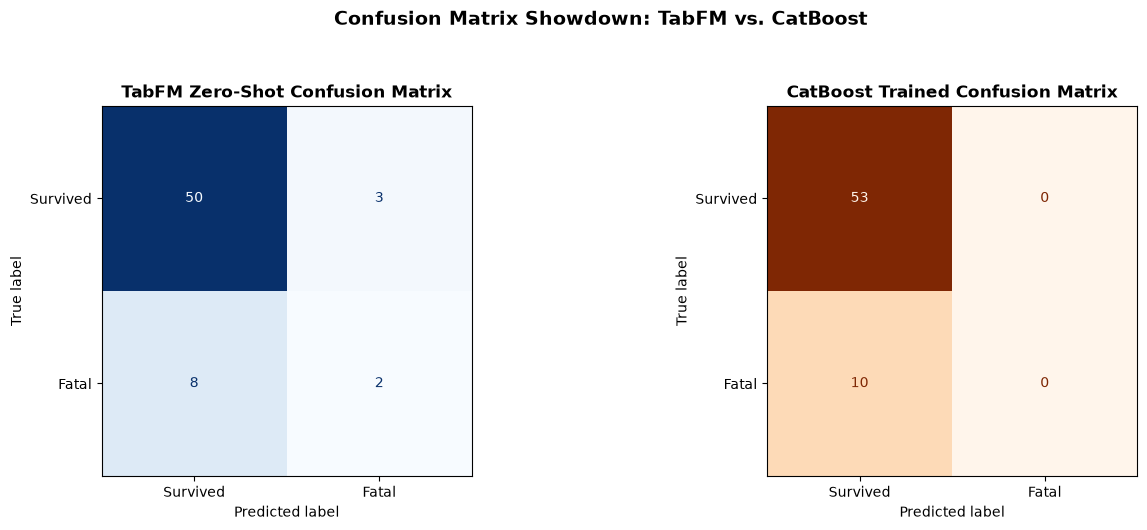

In [17]:
print(f"--- Performance Showdown ---")
print(f"TabFM Zero-Shot AUC:  {tabfm_auc:.4f}")
print(f"CatBoost Trained AUC: {cat_auc:.4f}")

# Threshold predictions to compute classification reports
tabfm_preds = (tabfm_probs >= 0.5).astype(int)
cat_preds = (cat_probs >= 0.5).astype(int)

print("\n--- TabFM Classification Report ---")
print(classification_report(y_test, tabfm_preds, target_names=["Survived", "Fatal"]))

print("--- CatBoost Classification Report ---")
print(classification_report(y_test, cat_preds, target_names=["Survived", "Fatal"]))

# Plot ROC Curves
fpr_tabfm, tpr_tabfm, _ = roc_curve(y_test, tabfm_probs)
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_tabfm, tpr_tabfm, label=f"TabFM Zero-Shot (AUC = {tabfm_auc:.4f})", color="royalblue", lw=2)
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost Trained (AUC = {cat_auc:.4f})", color="coral", lw=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Showdown: Zero-Shot TabFM vs. Supervised CatBoost")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ==========================================
# CONFUSION MATRIX SHOWDOWN
# ==========================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_tabfm = confusion_matrix(y_test, tabfm_preds)
cm_cat = confusion_matrix(y_test, cat_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot TabFM Confusion Matrix
cmd_tabfm = ConfusionMatrixDisplay(confusion_matrix=cm_tabfm, display_labels=["Survived", "Fatal"])
cmd_tabfm.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("TabFM Zero-Shot Confusion Matrix", fontsize=12, fontweight="bold")
axes[0].grid(False)

# Plot CatBoost Confusion Matrix
cmd_cat = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=["Survived", "Fatal"])
cmd_cat.plot(ax=axes[1], cmap="Oranges", colorbar=False)
axes[1].set_title("CatBoost Trained Confusion Matrix", fontsize=12, fontweight="bold")
axes[1].grid(False)

plt.suptitle("Confusion Matrix Showdown: TabFM vs. CatBoost", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

## 7. Calibration Showdown & The Probability Trade-off
While **ROC AUC** measures a model's ability to *rank* cases (e.g. is a fatal attack scored higher than a non-fatal one?), a model's **calibration** measures whether the predicted probabilities match real-world frequencies.
For example, if a model predicts a 30% chance of fatality, do exactly 30 out of 100 similar incidents result in death?

Let's plot the Calibration Curves (Reliability Diagrams) for both models.

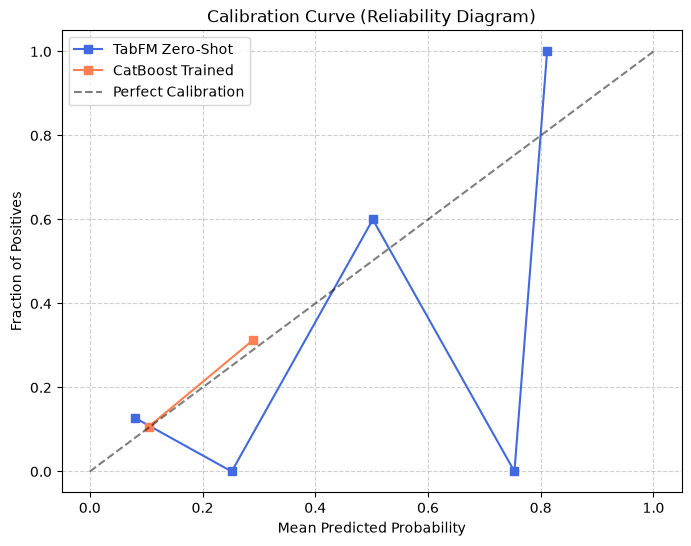

In [18]:
# Compute calibration curves
prob_true_tabfm, prob_pred_tabfm = calibration_curve(y_test, tabfm_probs, n_bins=5)
prob_true_cat, prob_pred_cat = calibration_curve(y_test, cat_probs, n_bins=5)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred_tabfm, prob_true_tabfm, "s-", label="TabFM Zero-Shot", color="royalblue")
plt.plot(prob_pred_cat, prob_true_cat, "s-", label="CatBoost Trained", color="coral")
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration", alpha=0.5)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## 8. Core Data Science Revelations & Takeaways

### 1. The In-Context Paradigm Shift
TabFM did not execute a single gradient backpropagation step on the Hawaii shark attack data. It simply read `X_context` as a semantic prompt inside its attention window. 
This means you can instantly update predictions by simply appending new incidents to the context pool at inference time—**no retraining or scheduled cron jobs required!**

### 2. Implicit Feature Engineering
Traditional models treat words in isolation (e.g. TF-IDF). TabFM’s internal Transformers compress entire row cross-attentions. It knows that the combination of `"Spearfishing"` and `"Thigh laceration"` represents a fundamentally different level of risk than `"Wading"` and `"Thigh laceration"`, capturing these deep interactions on the fly without needing explicit feature engineering or cross-products.

### 3. The Calibration Trade-off
While TabFM is highly effective at ranking risk (ranking AUC), its zero-shot probability estimates might not be perfectly calibrated to the real-world baseline fatality rate of Hawaii shark attacks. 
A supervised model like CatBoost, trained directly on the target distribution, naturally aligns its outputs with the baseline rate. For zero-shot models, applying a post-processing step like **Platt Scaling** or **Isotonic Regression** on a small validation set is crucial to make the raw probabilities reliable for operational decision-making.